# 04 — Noisy-OR Risk Propagation

`r(v) = 1 - (1 - b(v)) * prod(1 - alpha_eff(u) * r(u))` over the dependency DAG, sweeping
alpha for three transmission variants. alpha=0 reproduces the base model exactly, so the sweep
is a non-inferiority curve; a paired bootstrap must clear BOTH an absolute AUROC margin and a
relative PR-AUC margin. The winner is written to `best_alpha.json` (read by notebooks 05/06).


## 1. Imports & config

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

from common import (BUCKET_ORDER, ECO_TITLES, MIN_PER_CLASS, MIN_VIEW_POS, N_JOBS, SEED,
                    build_graph_structures, make_views, reach_weighted_sums,
                    read_csv_literal, to_bucket)

ECO       = os.environ.get("ECO", "npm")
ECO_TITLE = ECO_TITLES[ECO]

ROOT    = Path("..")
PREP    = ROOT / "data" / "output" / ECO / "01_data_prep"
TRAIN   = ROOT / "data" / "output" / ECO / "02_model_training"
OUT_DIR = ROOT / "data" / "output" / ECO / "04_noisy-or-sweep"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA_GRID    = np.round(np.arange(0.0, 1.001, 0.1), 2)   # alpha = 0 -> base model
VARIANTS      = ["Unweighted", "Weighted (dp)", "Weighted (log dp)"]
NI_MARGIN     = 0.01     # absolute non-inferiority margin on AUROC
NI_MARGIN_REL = 0.10     # relative margin on PR-AUC (fraction of the base PR-AUC)
N_BOOT        = 300      # paired bootstrap resamples
EXPOSED_BASE_MAX = 0.05  # "metadata says clean" cut for the audit list

VAR_STYLE = {"Unweighted": ("#2a78d6", "o"), "Weighted (dp)": ("#008300", "^"),
             "Weighted (log dp)": ("#eb6834", "s")}
CLR_BASE = "#85847c"
VERDICT_COLOR = {"superior": "#008300", "non-inferior": "#2a78d6", "DEGRADED": "#e34948"}

t_nb = time.time()
print(f"{ECO_TITLE} | out: {OUT_DIR.resolve()}")


npm | out: C:\Users\amehs\Documents\ThesisAppendixVersion\data\output\npm\04_noisy-or-sweep


## 2. Load the corpus, the graph and notebook 02's chosen model

In [2]:
schema = json.loads((PREP / "schema.json").read_text(encoding="utf-8"))
best_cfg = json.loads((TRAIN / "best_model.json").read_text(encoding="utf-8"))["best_per_view"]
df = read_csv_literal(PREP / "model_ready_dataset.csv")
gf = read_csv_literal(PREP / "graph_features.csv")
edges = read_csv_literal(PREP / "edges.csv")
assert (df["package"] == gf["package"]).all() and len(df) == schema["n_packages"]

N = len(df)
label_arr = df["label"].astype(int).to_numpy()
VIEWS = make_views(label_arr, restrict_to=best_cfg)

ETM_FEATURES, DTM_FEATURES = schema["etm_features"], schema["dtm_features"]
FEATURE_SETS = {"MeMPtec_E": ETM_FEATURES, "MeMPtec_D": DTM_FEATURES,
                "MeMPtec": ETM_FEATURES + DTM_FEATURES}

pos_of = {p: i for i, p in enumerate(df["package"])}
src = edges["source"].map(pos_of).to_numpy(dtype=np.int64)
tgt = edges["target"].map(pos_of).to_numpy(dtype=np.int64)
conn_pkg = gf["connected"].to_numpy(dtype=bool)

print(f"{ECO_TITLE}: {N:,} packages | {len(src):,} edges | connected {int(conn_pkg.sum()):,}")
for v, cfg in best_cfg.items():
    mark = "" if v in VIEWS else "   (view unusable here)"
    print(f"  notebook 02 best for {v:12s}: {cfg['model']} / {cfg['feature_set']} "
          f"(F1={cfg['f1_mean']:.4f}){mark}")

npm: 101,350 packages | 388,416 edges | connected 85,279
  notebook 02 best for compromised : GBM / MeMPtec (F1=0.9181)
  notebook 02 best for risky       : DRF / MeMPtec (F1=0.6244)


## 3. Graph substrate

In [3]:
gs = build_graph_structures(src, tgt, N)
n_scc, scc, lev, topo = gs["n_scc"], gs["scc"], gs["lev"], gs["topo"]
scc_size = np.bincount(scc, minlength=n_scc).astype(np.float64)
level_pkg = lev[scc]; maxlev = int(lev.max())
drive = reach_weighted_sums(gs["inf_csr"].indptr, gs["inf_csr"].indices, topo[::-1],
                            scc_size[:, None], label="driving")
dp_scc = drive[:, 0] - 1.0
driving_power = dp_scc[scc]

bucket_pkg = np.array([to_bucket(l, not c) for l, c in zip(level_pkg, conn_pkg)])

print(f"SCCs {n_scc:,} | max Warfield level {maxlev} | "
      f"driving>0 for {int((driving_power>0).sum()):,} packages")


  reachability [driving] 45.0s
SCCs 100,415 | max Warfield level 151 | driving>0 for 49,967 packages


## 4. Base scores — out-of-fold, from notebook 02's chosen model

In [4]:
def make_model(name):
    svm_base = LinearSVC(max_iter=3000, C=1.0, class_weight="balanced", random_state=SEED)
    return {
        "SVM": Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler()),
                         ("clf", CalibratedClassifierCV(svm_base, cv=3))]),
        "GLM": Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler()),
                         ("clf", LogisticRegression(max_iter=2000, C=1.0,
                                                    class_weight="balanced",
                                                    solver="lbfgs", random_state=SEED))]),
        "GBM": HistGradientBoostingClassifier(max_iter=200, max_depth=5,
                                              class_weight="balanced", random_state=SEED),
        "DRF": RandomForestClassifier(n_estimators=300, n_jobs=N_JOBS,
                                      class_weight="balanced", random_state=SEED),
        "DL":  Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler()),
                         ("clf", MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                               activation="relu", solver="adam",
                                               max_iter=300, early_stopping=True,
                                               validation_fraction=0.1, random_state=SEED))]),
    }[name]


BASE = {}
for vname, v in VIEWS.items():
    cfg = best_cfg[vname]
    sub = df[v["keep"]].reset_index(drop=True); y = v["y"]
    X = sub[FEATURE_SETS[cfg["feature_set"]]].apply(pd.to_numeric, errors="coerce") \
           .values.astype(np.float32)
    oof = np.zeros(len(sub)); filled = np.zeros(len(sub), bool)
    t0 = time.time()
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y):
        m = make_model(cfg["model"]).fit(X[tr], y[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]; filled[te] = True
    assert filled.all() and np.isfinite(oof).all()
    # lift back to full-corpus indexing (rows outside the view keep score 0 and are never scored)
    full = np.zeros(N); full[np.flatnonzero(v["keep"])] = oof
    BASE[vname] = {"score": full, "idx": np.flatnonzero(v["keep"]), "y": y,
                   "auroc": float(roc_auc_score(y, oof)),
                   "prauc": float(average_precision_score(y, oof))}
    print(f"  {vname:12s} base = {cfg['model']}/{cfg['feature_set']}: "
          f"ROC-AUC={BASE[vname]['auroc']:.4f} PR-AUC={BASE[vname]['prauc']:.4f} "
          f"({time.time()-t0:.0f}s)")

  compromised  base = GBM/MeMPtec: ROC-AUC=0.9920 PR-AUC=0.9282 (74s)
  risky        base = DRF/MeMPtec: ROC-AUC=0.9121 PR-AUC=0.6261 (144s)


## 5. The Noisy-OR gate

In [5]:
E_dep = gs["dag_edges"][:, 0].astype(np.int64)   # depends on ...
E_dpy = gs["dag_edges"][:, 1].astype(np.int64)   # ... this dependency (strictly lower level)
if len(E_dep):
    _o = np.argsort(lev[E_dep], kind="stable")
    E_dep, E_dpy = E_dep[_o], E_dpy[_o]
    lev_start = np.searchsorted(lev[E_dep], np.arange(maxlev + 2))
else:
    lev_start = np.zeros(maxlev + 2, np.int64)
nodes_by_level = [np.flatnonzero(lev == L) for L in range(maxlev + 1)]

W_SCC = {"Unweighted": None,
         "Weighted (dp)": dp_scc / max(dp_scc.max(), 1.0),
         "Weighted (log dp)": np.log1p(np.maximum(dp_scc, 0)) / max(np.log1p(dp_scc.max()), 1e-12)}


def scc_max(seed_pkg):
    b = np.zeros(n_scc); np.maximum.at(b, scc, seed_pkg); return b


def noisy_or_propagate(base_scc, alpha, w_scc=None):
    # level-synchronous Noisy-OR over the condensation; returns (risk, ancestors-only)
    r = np.asarray(base_scc, dtype=np.float64).copy()
    logacc = np.zeros(n_scc)
    for L in range(1, maxlev + 1):
        a, b = int(lev_start[L]), int(lev_start[L + 1])
        if b > a:
            ae = alpha if w_scc is None else alpha * w_scc[E_dpy[a:b]]
            np.add.at(logacc, E_dep[a:b],
                      np.log(np.clip(1.0 - ae * r[E_dpy[a:b]], 1e-300, 1.0)))
        nds = nodes_by_level[L]
        if len(nds):
            r[nds] = 1.0 - (1.0 - base_scc[nds]) * np.exp(logacc[nds])
    return np.clip(r, 0.0, 1.0), np.clip(1.0 - np.exp(logacc), 0.0, 1.0)


def propagate_pkg(seed_pkg, alpha, variant):
    # transmit on the condensation, then recombine with each package's OWN base score,
    # so alpha=0 returns the base model exactly rather than the SCC maximum
    _, a_scc = noisy_or_propagate(scc_max(seed_pkg), alpha, W_SCC[variant])
    anc = a_scc[scc]
    return 1.0 - (1.0 - seed_pkg) * (1.0 - anc), anc


print("Noisy-OR gate ready.")

Noisy-OR gate ready.


## 6. The α sweep

In [6]:
def per_level_auroc(score, yv, idx):
    rows = []
    for b in BUCKET_ORDER:
        m = bucket_pkg[idx] == b
        if m.sum() == 0:
            continue
        yb = yv[m]
        if yb.sum() < MIN_PER_CLASS or (yb == 0).sum() < MIN_PER_CLASS:
            continue
        rows.append({"level_bucket": b, "n": int(m.sum()), "n_pos": int(yb.sum()),
                     "auroc": float(roc_auc_score(yb, score[m]))})
    return pd.DataFrame(rows)


sweep_rows, cache = [], {}
for vname, B in BASE.items():
    idx, y = B["idx"], B["y"]
    # exposure: clean packages with >=1 positive transitive dependency
    pos_full = np.zeros(N); pos_full[idx] = y
    pos_scc = np.bincount(scc, weights=pos_full, minlength=n_scc)
    anc_pos = reach_weighted_sums(gs["dep_csr"].indptr, gs["dep_csr"].indices, topo,
                                  pos_scc[:, None], label=f"exposure/{vname}")[scc, 0] - pos_full
    exposed_full = (pos_full == 0) & (anc_pos > 0)
    cache[(vname, "exposed")] = exposed_full
    cache[(vname, "anc_pos")] = anc_pos

    t0 = time.time()
    for variant in VARIANTS:
        for alpha in ALPHA_GRID:
            prop_full, anc_full = propagate_pkg(B["score"], float(alpha), variant)
            cache[(vname, variant, float(alpha))] = (prop_full, anc_full)
            p, base = prop_full[idx], B["score"][idx]
            lvl = per_level_auroc(p, y, idx)
            sweep_rows.append({
                "view": vname, "variant": variant, "alpha": float(alpha),
                "auroc": float(roc_auc_score(y, p)),
                "prauc": float(average_precision_score(y, p)),
                "mean_level_auroc": float(lvl["auroc"].mean()) if len(lvl) else np.nan,
                "n_level_buckets": int(len(lvl)),
                "n_lifted": int((prop_full > B["score"] + 1e-12).sum()),
                "mean_lift_exposed": float((prop_full - B["score"])[exposed_full].mean())
                                     if exposed_full.any() else np.nan,
            })
        print(f"  [{vname:11s}] {variant:18s} swept ({time.time()-t0:.0f}s)")

sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(OUT_DIR / "alpha_sweep.csv", index=False)
for vname in BASE:
    print(f"\n=== {vname} — AUROC (alpha=0 is the base model) ===")
    print(sweep[sweep.view == vname].pivot(index="alpha", columns="variant", values="auroc")
          .to_string(float_format="{:.4f}".format))
    print(f"--- PR-AUC ---")
    print(sweep[sweep.view == vname].pivot(index="alpha", columns="variant", values="prauc")
          .to_string(float_format="{:.4f}".format))

  reachability [exposure/compromised] 35.0s
  [compromised] Unweighted         swept (2s)
  [compromised] Weighted (dp)      swept (4s)
  [compromised] Weighted (log dp)  swept (6s)
  reachability [exposure/risky] 35.1s
  [risky      ] Unweighted         swept (2s)
  [risky      ] Weighted (dp)      swept (4s)
  [risky      ] Weighted (log dp)  swept (6s)

=== compromised — AUROC (alpha=0 is the base model) ===
variant  Unweighted  Weighted (dp)  Weighted (log dp)
alpha                                                
0.0          0.9920         0.9920             0.9920
0.1          0.9916         0.9924             0.9926
0.2          0.9882         0.9924             0.9919
0.3          0.9845         0.9924             0.9901
0.4          0.9802         0.9924             0.9881
0.5          0.9740         0.9923             0.9859
0.6          0.9660         0.9922             0.9837
0.7          0.9557         0.9922             0.9810
0.8          0.9420         0.9920           

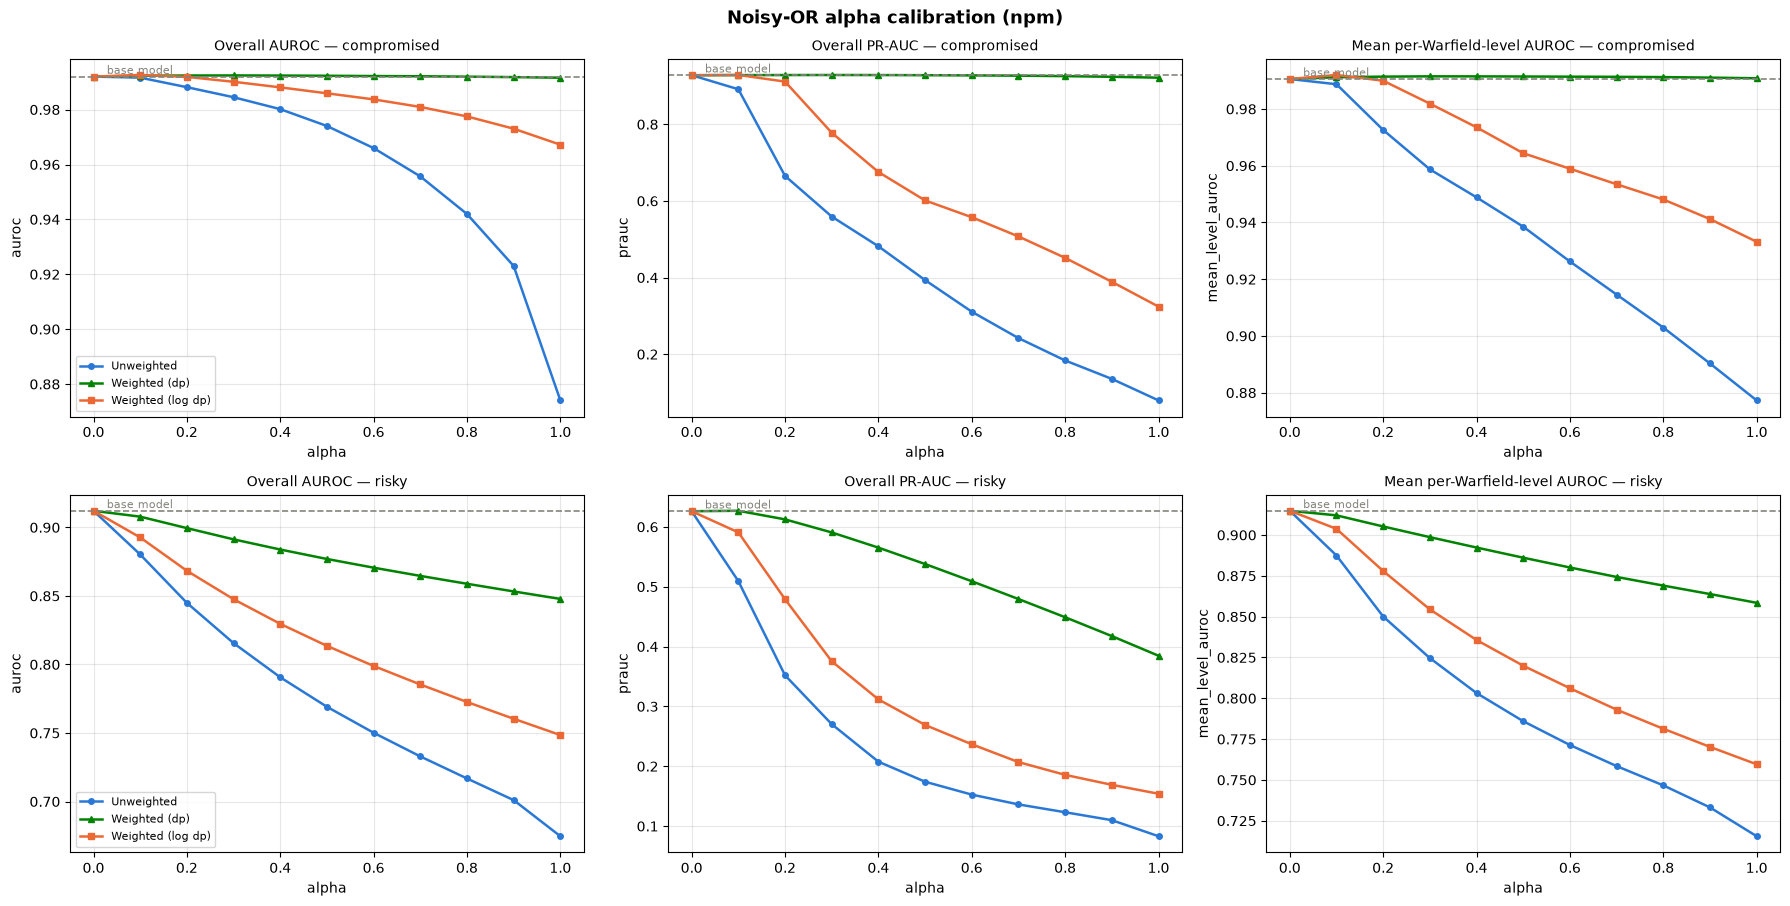

In [7]:
n_v = len(BASE)
fig, axes = plt.subplots(n_v, 3, figsize=(18, 4.6 * n_v), squeeze=False)
for i, vname in enumerate(BASE):
    B = BASE[vname]
    s_all = sweep[sweep.view == vname]
    base_lvl = per_level_auroc(B["score"][B["idx"]], B["y"], B["idx"])
    base_mlvl = float(base_lvl["auroc"].mean()) if len(base_lvl) else np.nan
    panels = [("auroc", "Overall AUROC", B["auroc"]),
              ("prauc", "Overall PR-AUC", B["prauc"]),
              ("mean_level_auroc", "Mean per-Warfield-level AUROC", base_mlvl)]
    for ax, (col, ttl, baseval) in zip(axes[i], panels):
        for variant in VARIANTS:
            s = s_all[s_all.variant == variant].sort_values("alpha")
            c, mk = VAR_STYLE[variant]
            ax.plot(s.alpha, s[col], marker=mk, ms=4, lw=1.8, color=c, label=variant)
        ax.axhline(baseval, color=CLR_BASE, ls="--", lw=1.2)
        ax.text(0.02, baseval, " base model", va="bottom", fontsize=8, color=CLR_BASE)
        ax.set_xlabel("alpha"); ax.set_ylabel(col)
        ax.set_title(f"{ttl} — {vname}", fontsize=10); ax.grid(alpha=0.3)
    axes[i][0].legend(fontsize=8, loc="lower left")
fig.suptitle(f"Noisy-OR alpha calibration ({ECO_TITLE})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "alpha_sweep.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 7. Non-inferiority against the base model

In [8]:
def paired_bootstrap(a, b, yv, n_boot=N_BOOT, seed=SEED):
    pos = np.flatnonzero(yv == 1); neg = np.flatnonzero(yv == 0)
    br = np.random.default_rng(seed)
    d_auc, d_ap = np.empty(n_boot), np.empty(n_boot)
    for i in range(n_boot):
        idx = np.concatenate([br.choice(pos, len(pos), replace=True),
                              br.choice(neg, len(neg), replace=True)])
        yb = yv[idx]
        d_auc[i] = roc_auc_score(yb, b[idx]) - roc_auc_score(yb, a[idx])
        d_ap[i] = average_precision_score(yb, b[idx]) - average_precision_score(yb, a[idx])
    q = lambda x: (float(np.percentile(x, 2.5)), float(np.percentile(x, 97.5)))
    return (float(d_auc.mean()), *q(d_auc)), (float(d_ap.mean()), *q(d_ap))


def grade(lo, margin):
    return "superior" if lo > 0 else "non-inferior" if lo > -margin else "DEGRADED"


ni_rows = []
for vname, B in BASE.items():
    idx, y, base = B["idx"], B["y"], B["score"]
    pr_margin = NI_MARGIN_REL * B["prauc"]
    s_v = sweep[sweep.view == vname]
    best_a = float(s_v[s_v.alpha > 0].sort_values("mean_level_auroc", ascending=False).iloc[0]["alpha"])
    headline = sorted({0.2, best_a, 1.0})
    t0 = time.time()
    for variant in VARIANTS:
        for alpha in headline:
            prop = cache[(vname, variant, float(alpha))][0]
            (da, da_lo, da_hi), (dp_, dp_lo, dp_hi) = paired_bootstrap(base[idx], prop[idx], y)
            g_a, g_p = grade(da_lo, NI_MARGIN), grade(dp_lo, pr_margin)
            ni_rows.append({
                "view": vname, "variant": variant, "alpha": alpha,
                "AUROC prop": float(roc_auc_score(y, prop[idx])),
                "PR-AUC prop": float(average_precision_score(y, prop[idx])),
                "dAUROC": da, "dAUROC lo": da_lo, "dAUROC hi": da_hi,
                "dPR-AUC": dp_, "dPR-AUC lo": dp_lo, "dPR-AUC hi": dp_hi,
                "AUROC verdict": g_a, "PR-AUC verdict": g_p,
                "verdict": ("DEGRADED" if "DEGRADED" in (g_a, g_p)
                            else "superior" if g_a == g_p == "superior" else "non-inferior"),
            })
        print(f"  [{vname:11s}] bootstrapped {variant} ({time.time()-t0:.0f}s)")

ni = pd.DataFrame(ni_rows)
ni.to_csv(OUT_DIR / "noninferiority.csv", index=False)
for vname, B in BASE.items():
    print(f"\n=== {vname}: base AUROC {B['auroc']:.4f} / PR-AUC {B['prauc']:.4f} | "
          f"margins -{NI_MARGIN} and -{NI_MARGIN_REL*B['prauc']:.4f} ===")
    print(ni[ni.view == vname].set_index(["variant", "alpha"])[
        ["AUROC prop", "dAUROC", "dAUROC lo", "PR-AUC prop", "dPR-AUC", "dPR-AUC lo",
         "AUROC verdict", "PR-AUC verdict", "verdict"]].to_string(float_format="{:.4f}".format))

  [compromised] bootstrapped Unweighted (124s)
  [compromised] bootstrapped Weighted (dp) (273s)
  [compromised] bootstrapped Weighted (log dp) (403s)
  [risky      ] bootstrapped Unweighted (140s)
  [risky      ] bootstrapped Weighted (dp) (273s)
  [risky      ] bootstrapped Weighted (log dp) (425s)

=== compromised: base AUROC 0.9920 / PR-AUC 0.9282 | margins -0.01 and -0.0928 ===
                         AUROC prop  dAUROC  dAUROC lo  PR-AUC prop  dPR-AUC  dPR-AUC lo AUROC verdict PR-AUC verdict       verdict
variant           alpha                                                                                                            
Unweighted        0.1        0.9916 -0.0004    -0.0013       0.8915  -0.0362     -0.0453  non-inferior   non-inferior  non-inferior
                  0.2        0.9882 -0.0039    -0.0050       0.6654  -0.2626     -0.2797  non-inferior       DEGRADED      DEGRADED
                  1.0        0.8741 -0.1179    -0.1216       0.0795  -0.8486     -0.85

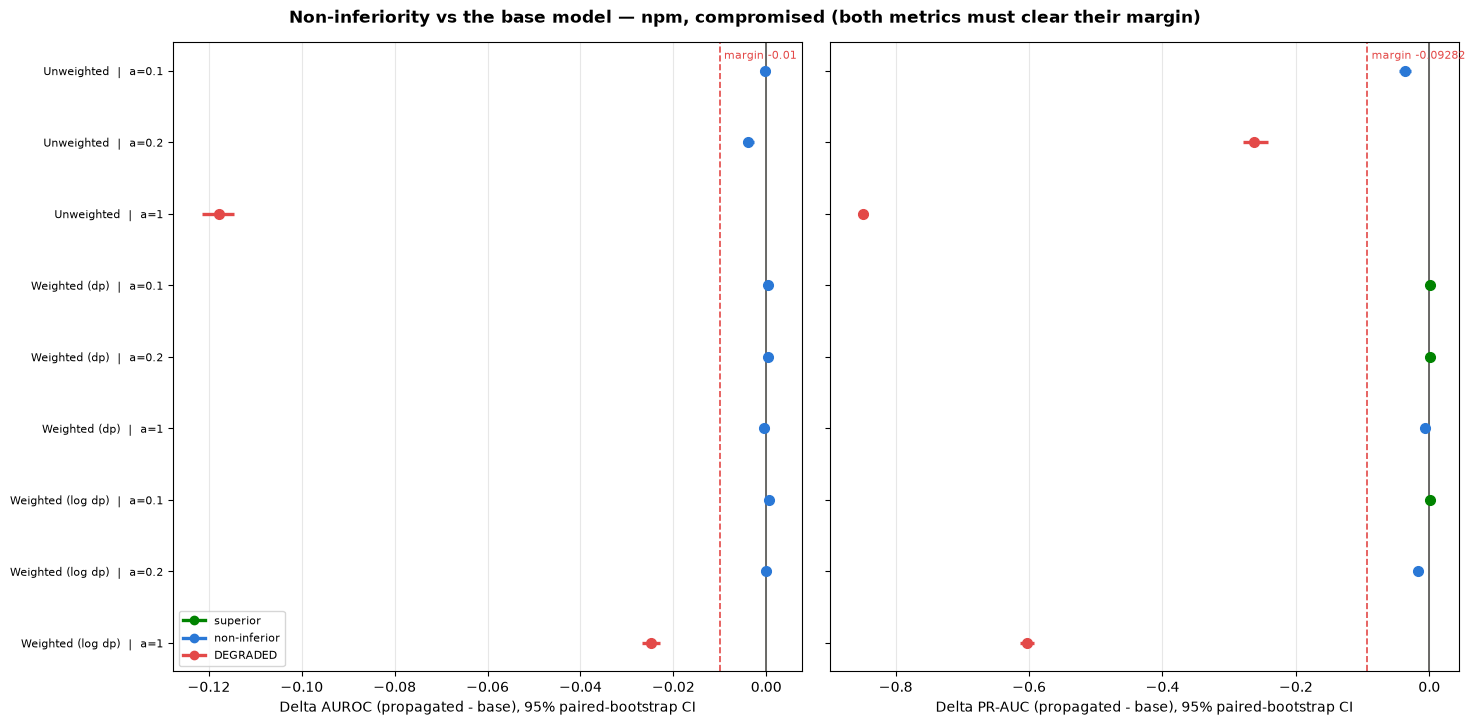

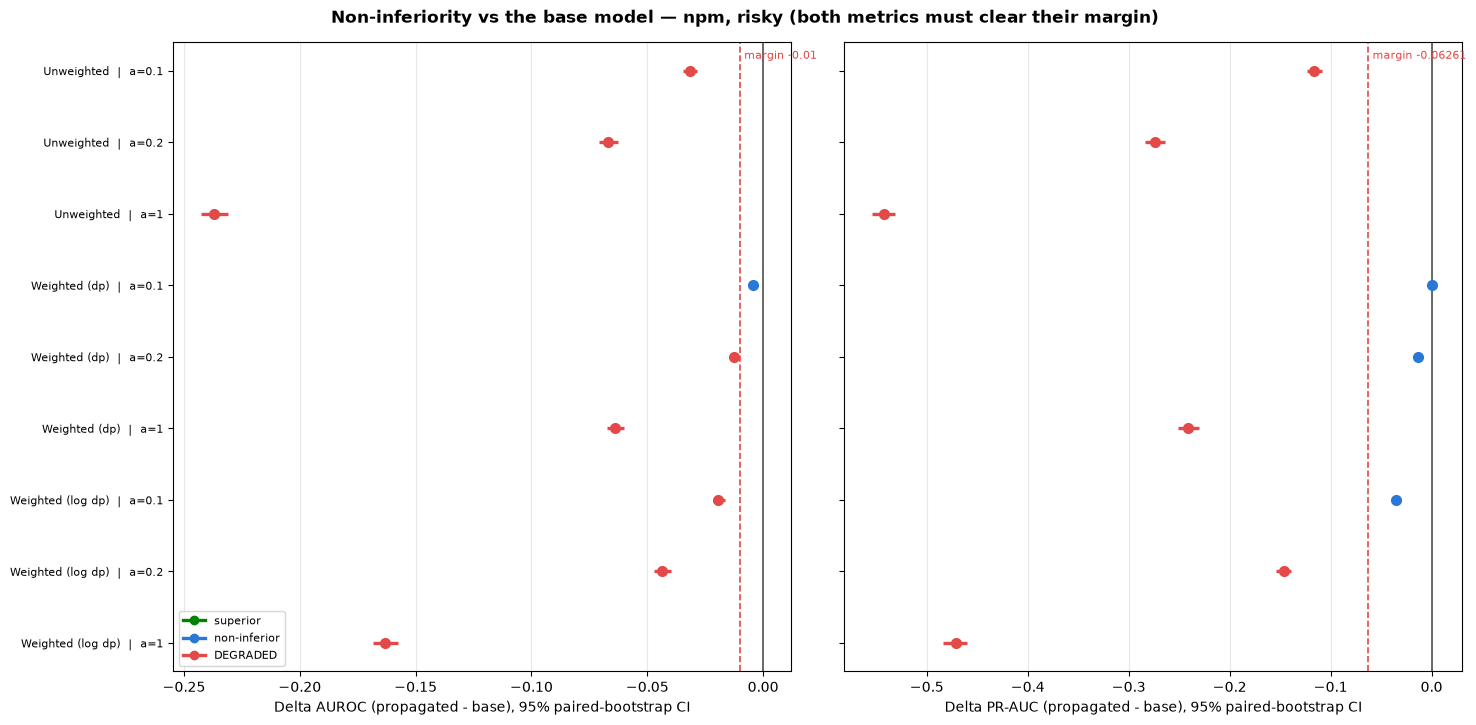

In [9]:
for vname, B in BASE.items():
    sub = ni[ni.view == vname].reset_index(drop=True)
    pr_margin = NI_MARGIN_REL * B["prauc"]
    yy = np.arange(len(sub))[::-1]
    fig, axes = plt.subplots(1, 2, figsize=(15, 0.55 * len(sub) + 2.4), sharey=True)
    for ax, col, vcol, margin, xlab in [
            (axes[0], "dAUROC", "AUROC verdict", NI_MARGIN, "Delta AUROC"),
            (axes[1], "dPR-AUC", "PR-AUC verdict", pr_margin, "Delta PR-AUC")]:
        for yi, (_, r) in zip(yy, sub.iterrows()):
            c = VERDICT_COLOR[r[vcol]]
            ax.plot([r[f"{col} lo"], r[f"{col} hi"]], [yi, yi], color=c, lw=2.4,
                    solid_capstyle="butt")
            ax.plot([r[col]], [yi], marker="o", ms=7, color=c, zorder=5)
        ax.axvline(0, color="#52514e", lw=1.2)
        ax.axvline(-margin, color="#e34948", ls="--", lw=1.2)
        ax.annotate(f"margin -{margin:.4g}", xy=(-margin, 1.0),
                    xycoords=("data", "axes fraction"), xytext=(3, -6),
                    textcoords="offset points", color="#e34948", fontsize=8, va="top")
        ax.set_xlabel(f"{xlab} (propagated - base), 95% paired-bootstrap CI")
        ax.grid(axis="x", alpha=0.3)
    for v, c in VERDICT_COLOR.items():
        axes[0].plot([], [], color=c, lw=2.4, marker="o", ms=6, label=v)
    axes[0].legend(fontsize=8, loc="lower left")
    axes[0].set_yticks(yy)
    axes[0].set_yticklabels([f"{r['variant']}  |  a={r['alpha']:g}"
                             for _, r in sub.iterrows()], fontsize=8)
    fig.suptitle(f"Non-inferiority vs the base model — {ECO_TITLE}, {vname} "
                 f"(both metrics must clear their margin)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"noninferiority_{vname}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 8. The winner, and what propagation buys

In [10]:
best_alpha = {}
for vname, B in BASE.items():
    # the PR-AUC argmax over the whole sweep, regardless of verdict: notebook 06 asks a
    # different question (does propagation help a scarcity detector?) and needs a
    # non-degenerate setting even where propagation degrades the base score here.
    s_pos = sweep[(sweep.view == vname) & (sweep.alpha > 0)]
    r_pr = s_pos.sort_values("prauc", ascending=False).iloc[0]
    sub = ni[(ni.view == vname) & (ni.verdict != "DEGRADED")]
    if len(sub):
        r = sub.sort_values("PR-AUC prop", ascending=False).iloc[0]
        best_alpha[vname] = {"alpha": float(r["alpha"]), "variant": str(r["variant"]),
                             "verdict": str(r["verdict"]),
                             "auroc": float(r["AUROC prop"]), "prauc": float(r["PR-AUC prop"]),
                             "base_auroc": B["auroc"], "base_prauc": B["prauc"],
                             "propagation_recommended": True,
                             "alpha_best_prauc": float(r_pr["alpha"]),
                             "variant_best_prauc": str(r_pr["variant"])}
        print(f"{vname:12s} -> {r['variant']} @ alpha={r['alpha']:g} ({r['verdict']}): "
              f"AUROC {B['auroc']:.4f}->{r['AUROC prop']:.4f}, "
              f"PR-AUC {B['prauc']:.4f}->{r['PR-AUC prop']:.4f}")
    else:
        best_alpha[vname] = {"alpha": 0.0, "variant": "Unweighted", "verdict": "none survived",
                             "auroc": B["auroc"], "prauc": B["prauc"],
                             "base_auroc": B["auroc"], "base_prauc": B["prauc"],
                             "propagation_recommended": False,
                             "alpha_best_prauc": float(r_pr["alpha"]),
                             "variant_best_prauc": str(r_pr["variant"])}
        print(f"{vname:12s} -> NO configuration cleared both margins; "
              f"recording alpha=0 (propagation off) for notebook 06.")

(OUT_DIR / "best_alpha.json").write_text(
    json.dumps({"ecosystem": ECO, "best_per_view": best_alpha}, indent=2), encoding="utf-8")
print(f"\nsaved {OUT_DIR/'best_alpha.json'}")

compromised  -> Weighted (log dp) @ alpha=0.1 (non-inferior): AUROC 0.9920->0.9926, PR-AUC 0.9282->0.9289
risky        -> Weighted (dp) @ alpha=0.1 (non-inferior): AUROC 0.9121->0.9078, PR-AUC 0.6261->0.6268

saved ..\data\output\npm\04_noisy-or-sweep\best_alpha.json


In [11]:
# audit payoff: clean packages the graph elevates above what metadata sees
audit_all, score_all = [], []
for vname, B in BASE.items():
    cfgb = best_alpha[vname]
    if cfgb["propagation_recommended"]:
        a, variant = cfgb["alpha"], cfgb["variant"]
        note = f"{variant} @ alpha={a:g} (recommended)"
    else:
        # nothing cleared both margins: show the least-bad setting, clearly labelled, so the
        # section still says WHAT propagation would have surfaced -- alpha=0 would be all zeros.
        s_v = sweep[(sweep.view == vname) & (sweep.alpha > 0)]
        r = s_v.sort_values("mean_level_auroc", ascending=False).iloc[0]
        a, variant = float(r["alpha"]), str(r["variant"])
        note = (f"{variant} @ alpha={a:g}  [DIAGNOSTIC ONLY — this configuration degraded the "
                f"base model, so notebook 06 will run with propagation off]")
    print(f"\n--- {vname}: {note}")
    prop, anc = cache[(vname, variant, float(a))]
    exposed = cache[(vname, "exposed")]
    shift = pd.DataFrame({
        "view": vname, "package": df["package"].to_numpy(), "label": label_arr,
        "level_bucket": bucket_pkg, "n_positive_deps": cache[(vname, "anc_pos")],
        "base": B["score"], "prop": prop, "ancestor_risk": anc, "exposed": exposed})
    shift["lift"] = shift["prop"] - shift["base"]
    top = (shift[shift.exposed & (shift.base < EXPOSED_BASE_MAX)]
           .nlargest(50, "lift").reset_index(drop=True))
    audit_all.append(top)
    score_all.append(shift[["view", "package", "base", "prop", "ancestor_risk", "exposed"]])
    print(f"    exposed clean packages: {int(exposed.sum()):,} "
          f"({100*exposed.mean():.1f}% of corpus) | mean lift "
          f"{shift[shift.exposed]['lift'].mean():.4f}")
    if len(top):
        print(top[["package", "base", "prop", "lift"]].head(10)
              .to_string(index=False, float_format="{:.4f}".format))
    else:
        print("  (no exposed clean package under the base<%.2f cut)" % EXPOSED_BASE_MAX)
pd.concat(audit_all, ignore_index=True).to_csv(OUT_DIR / "audit_priority.csv", index=False)
# the base and propagated scores notebook 05 ranks with (one block per label view)
pd.concat(score_all, ignore_index=True).to_csv(OUT_DIR / "base_scores.csv", index=False)
print("saved", OUT_DIR / "base_scores.csv")


--- compromised: Weighted (log dp) @ alpha=0.1 (recommended)
    exposed clean packages: 18,981 (18.7% of corpus) | mean lift 0.0210
              package   base   prop   lift
                jamet 0.0020 0.3942 0.3922
 browser-string-hexer 0.0134 0.3745 0.3611
               gatsby 0.0000 0.2722 0.2722
               cli-ux 0.0012 0.2696 0.2684
@commercelayer/cli-ux 0.0417 0.3059 0.2642
        @lerna/create 0.0009 0.2418 0.2409
              bit-bin 0.0071 0.2302 0.2232
      heroku-cli-util 0.0119 0.2343 0.2224
   @bytexbyte/bxb-api 0.0028 0.2248 0.2220
           antd-tools 0.0220 0.2434 0.2214

--- risky: Weighted (dp) @ alpha=0.1 (recommended)
    exposed clean packages: 42,758 (42.2% of corpus) | mean lift 0.0259
                       package   base   prop   lift
                         jamet 0.0333 0.5232 0.4899
          browser-string-hexer 0.0333 0.5145 0.4812
        @teambit/aspect-loader 0.0067 0.3582 0.3515
              @teambit/graphql 0.0067 0.3582 0.3515
      @ti

## 9. Summary

In [13]:
summary = {"ecosystem": ECO, "views": ",".join(BASE), "runtime_min": (time.time()-t_nb)/60}
for vname, B in BASE.items():
    b = best_alpha[vname]
    sub = ni[ni.view == vname]
    summary[f"{vname}_base_model"] = f"{best_cfg[vname]['model']}/{best_cfg[vname]['feature_set']}"
    summary[f"{vname}_base_auroc"] = round(B["auroc"], 4)
    summary[f"{vname}_base_prauc"] = round(B["prauc"], 4)
    summary[f"{vname}_best_variant"] = b["variant"]
    summary[f"{vname}_best_alpha"] = b["alpha"]
    summary[f"{vname}_verdict"] = b["verdict"]
    summary[f"{vname}_prop_auroc"] = round(b["auroc"], 4)
    summary[f"{vname}_prop_prauc"] = round(b["prauc"], 4)
    summary[f"{vname}_n_surviving"] = int((sub.verdict != "DEGRADED").sum())
    summary[f"{vname}_n_tested"] = int(len(sub))
    summary[f"{vname}_n_exposed_clean"] = int(cache[(vname, "exposed")].sum())
pd.Series(summary).to_frame("value").to_csv(OUT_DIR / "summary.csv")
print(pd.Series(summary).to_string())

ecosystem                                    npm
views                          compromised,risky
runtime_min                             19.83179
compromised_base_model               GBM/MeMPtec
compromised_base_auroc                     0.992
compromised_base_prauc                    0.9282
compromised_best_variant       Weighted (log dp)
compromised_best_alpha                       0.1
compromised_verdict                 non-inferior
compromised_prop_auroc                    0.9926
compromised_prop_prauc                    0.9289
compromised_n_surviving                        6
compromised_n_tested                           9
compromised_n_exposed_clean                18981
risky_base_model                     DRF/MeMPtec
risky_base_auroc                          0.9121
risky_base_prauc                          0.6261
risky_best_variant                 Weighted (dp)
risky_best_alpha                             0.1
risky_verdict                       non-inferior
risky_prop_auroc    